In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from xgboost import XGBClassifier

In [20]:
df = pd.read_csv("resnet_features.csv")

print(df.shape)
df.head()

(1500, 514)


,image,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,resnet_502,resnet_503,resnet_504,resnet_505,resnet_506,resnet_507,resnet_508,resnet_509,resnet_510,resnet_511
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,1.503252,0.733779,1.513309,0.041626,1.466865,1.763368,0.650255,1.772707,...,1.685473,0.089838,0.565075,1.063030,0.742253,0.548735,0.977023,0.234568,1.384308,0.575205
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,0.279744,0.618367,0.540192,3.436490,2.076207,0.436047,0.290990,1.178626,0.741967,0.428287
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,0.877449,0.399507,0.964876,1.779683,0.078416,0.693545,0.508940,0.199606,0.018365,0.465379
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,1.335343,0.806069,1.044957,1.080118,0.747630,0.015274,0.673897,0.666867,0.717901,0.218544
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,0.982408,0.407484,0.560537,0.850064,0.370739,0.031080,0.542728,0.668791,0.933221,0.123311


In [21]:
X = df.drop(columns=["image", "label"]).values

y = df["label"].values

print(X.shape)
print(y.shape)

pd.Series(y).value_counts().sort_index()

(1500, 512)
(1500,)


0    500
1    500
2    500
Name: count, dtype: int64

### Define XGBoost Model

In [22]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss",

    tree_method="hist"
)

### 5-Fold Cross Validation

In [23]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracies = []

f1_scores = []

all_true = []

all_pred = []

### Training Loop

In [24]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    print("=" * 50)
    print(f"Fold {fold}")

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    f1 = f1_score(
        y_test,
        pred,
        average="weighted"
    )

    accuracies.append(acc)
    f1_scores.append(f1)

    all_true.extend(y_test)
    all_pred.extend(pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Weighted F1 : {f1:.4f}")

Fold 1
Accuracy : 0.6700
Weighted F1 : 0.6675
Fold 2
Accuracy : 0.6833
Weighted F1 : 0.6792
Fold 3
Accuracy : 0.6733
Weighted F1 : 0.6693
Fold 4
Accuracy : 0.6800
Weighted F1 : 0.6810
Fold 5
Accuracy : 0.6867
Weighted F1 : 0.6853


### Final Accuracy

In [25]:
print("=" * 60)

print("Average Accuracy :", np.mean(accuracies))

print("Average F1 Score :", np.mean(f1_scores))

Average Accuracy : 0.6786666666666668
Average F1 Score : 0.6764505222430073


### Classification Report

In [26]:
print(
    classification_report(
        all_true,
        all_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6979    0.7440    0.7202       500
           1     0.6959    0.7140    0.7048       500
           2     0.6366    0.5780    0.6059       500

    accuracy                         0.6787      1500
   macro avg     0.6768    0.6787    0.6770      1500
weighted avg     0.6768    0.6787    0.6770      1500



### Confusion Matrix

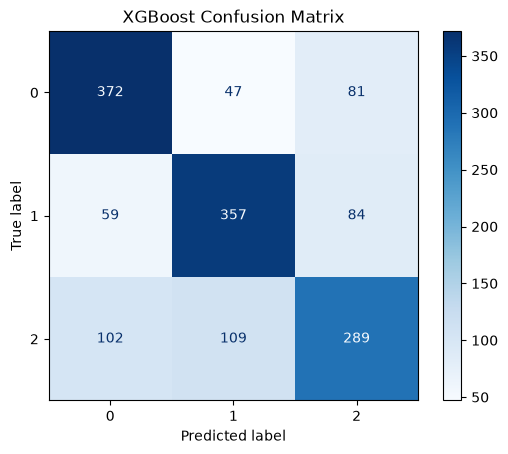

In [27]:
ConfusionMatrixDisplay.from_predictions(
    all_true,
    all_pred,
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.show()

### Feature Importance

In [28]:
importance = pd.DataFrame({
    "Feature": range(512),
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
273,273,0.013264
153,153,0.006617
147,147,0.006477
293,293,0.005604
415,415,0.005047
207,207,0.004781
159,159,0.004567
97,97,0.004358
320,320,0.004353
217,217,0.004349


### Plot Top Features

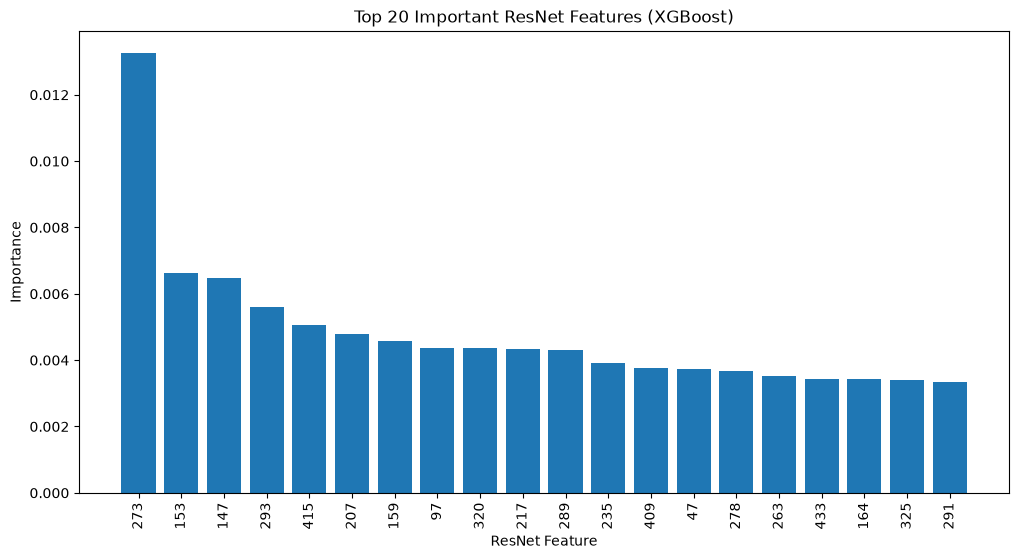

In [29]:
top20 = importance.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top20["Feature"].astype(str),
    top20["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("ResNet Feature")

plt.ylabel("Importance")

plt.title("Top 20 Important ResNet Features (XGBoost)")

plt.show()

### Conclution
✅ The ResNet18 embeddings are useful.

❌ The simple fully connected classification head wasn't extracting the best decision boundaries.

✅ A non-linear model like XGBoost can make much better use of the learned features.

### Hyperparameter tuning

### result -
I try manual hyperparameter tuning but it just make the accuracy worrst it decrease it to 64% 

### Load the Hybrid Dataset

In [30]:
import pandas as pd

hybrid_df = pd.read_csv("hybrid_features.csv")

print(hybrid_df.shape)

hybrid_df.head()

(1500, 537)


,id,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,l_mean,a_mean,b_mean,l_std,a_std,b_std,edge_density,laplacian_var,bright_ratio,dark_ratio
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,1.503252,0.733779,1.513309,0.041626,1.466865,1.763368,0.650255,1.772707,...,78.253960,125.864445,135.298550,45.371385,4.454920,5.600768,0.012070,219.483629,0.000000,0.347080
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,76.909702,123.298275,133.852314,39.861752,4.374290,3.988359,0.018215,229.052303,0.000000,0.272717
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,102.359478,128.527328,138.830452,49.641611,4.502393,5.323365,0.035538,281.944820,0.055027,0.188370
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,47.191967,122.214401,129.895306,30.074583,4.816540,6.653980,0.020493,237.096365,0.000000,0.674461
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,58.798435,116.122681,136.325592,34.338513,6.066670,4.152095,0.010010,225.819341,0.000000,0.628185


In [31]:
X = hybrid_df.drop(columns=["id", "label"])

y = hybrid_df["label"]

print(X.shape)
print(y.shape)

(1500, 535)
(1500,)


In [32]:
print("Total Features :", X.shape[1])

print("\nFirst 5 Features:")
print(X.columns[:5])

print("\nLast 10 Features:")
print(X.columns[-10:])

Total Features : 535

First 5 Features:
Index(['resnet_0', 'resnet_1', 'resnet_2', 'resnet_3', 'resnet_4'], dtype='str')

Last 10 Features:
Index(['l_mean', 'a_mean', 'b_mean', 'l_std', 'a_std', 'b_std', 'edge_density',
       'laplacian_var', 'bright_ratio', 'dark_ratio'],
      dtype='str')


In [33]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda"
)

### same XGBoost pipeline that gave 67.87% before.

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracies = []
f1_scores = []

conf_matrix = np.zeros((3,3), dtype=int)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda"
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracies.append(accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds, average="weighted"))

    conf_matrix += confusion_matrix(y_test, preds)

print("="*60)
print("Average Accuracy :", np.mean(accuracies))
print("Average F1 Score :", np.mean(f1_scores))
print("="*60)

print(classification_report(y_test, preds))
print(conf_matrix)

Average Accuracy : 0.68
Average F1 Score : 0.6778241311438075
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       100
           1       0.69      0.72      0.70       100
           2       0.63      0.59      0.61       100

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.68      0.68      0.68       300

[[376  50  74]
 [ 59 351  90]
 [ 93 114 293]]


## final stage
### submition

### Load the Test Dataset